<a href="https://colab.research.google.com/github/yuva0567890/23MID0421APAassignment5/blob/main/APA5DATASET2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 0 — Install Requirements

!pip -q install vaderSentiment transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Step 1 — Import Libraries

import os
import re
import time
import json
import platform
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

SEED = 42

np.random.seed(SEED)

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.13.15
Pandas: 2.2.3
NumPy: 2.1.3


In [ ]:
# Step 3 — BERTweet Libraries

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from torch.utils.data import Dataset as TorchDataset

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
# Step 4 — Load Dataset

DATA_PATH = "/content/twitter_training.csv"

raw4 = pd.read_csv(
    DATA_PATH,
    header=None,
    names=[
        "tweet_id",
        "entity",
        "sentiment",
        "text"
    ]
)

print("Dataset shape:", raw4.shape)

display(raw4.head())

Dataset shape: (74682, 4)


,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [ ]:
# Step 5 — Dataset Audit

print("Shape:", raw4.shape)

print("\nColumns:")
print(raw4.columns.tolist())

print("\nData Types:")
print(raw4.dtypes)

print("\nMissing Values:")
print(raw4.isnull().sum())

print("\nSentiment Classes:")
print(raw4["sentiment"].value_counts())

print("\nNumber of Entities:")
print(raw4["entity"].nunique())

Shape: (74682, 4)

Columns:
['tweet_id', 'entity', 'sentiment', 'text']

Data Types:
tweet_id      int64
entity       object
sentiment    object
text         object
dtype: object

Missing Values:
tweet_id       0
entity         0
sentiment      0
text         686
dtype: int64

Sentiment Classes:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Number of Entities:
32


In [ ]:
# Step 6 — Dataset Information

raw4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   74682 non-null  int64 
 1   entity     74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [ ]:
# Step 7 — Dataset Statistics

display(
    raw4.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tweet_id,74682.0,NaN,NaN,NaN,6432.586165,3740.42787,1.0,3195.0,6422.0,9601.0,13200.0
entity,74682,32,Microsoft,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment,74682,4,Negative,22542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,73996,69491,"At the same time, despite the fact that there ...",172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Step 8 — Duplicate Audit

print(
    "Duplicate IDs:",
    raw4["tweet_id"].duplicated().sum()
)

print(
    "Duplicate Texts:",
    raw4["text"].duplicated().sum()
)

Duplicate IDs: 62235
Duplicate Texts: 5190


In [ ]:
# Step 9 — Conflicting Duplicate Labels

text_label_check4 = (
    raw4.groupby("text")["sentiment"]
    .nunique()
)

conflicting4 = text_label_check4[
    text_label_check4 > 1
]

print(
    "Texts with conflicting labels:",
    len(conflicting4)
)

Texts with conflicting labels: 137


In [ ]:
# Step 10 — Missing Value Analysis

missing4 = raw4.isnull().sum()

missing_percentage4 = (
    missing4 / len(raw4) * 100
).round(2)

missing_table4 = pd.DataFrame({
    "Missing_Count": missing4,
    "Missing_Percentage": missing_percentage4
})

display(
    missing_table4.sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

,Missing_Count,Missing_Percentage
text,686,0.92
tweet_id,0,0.00
entity,0,0.00
sentiment,0,0.00


In [ ]:
# Step 11 — Sentiment Distribution

sentiment_counts4 = raw4["sentiment"].value_counts()

print(sentiment_counts4)

print("\nPercentages:")

display(
    raw4["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Percentages:


,proportion
sentiment,
Negative,30.18
Positive,27.89
Neutral,24.53
Irrelevant,17.39


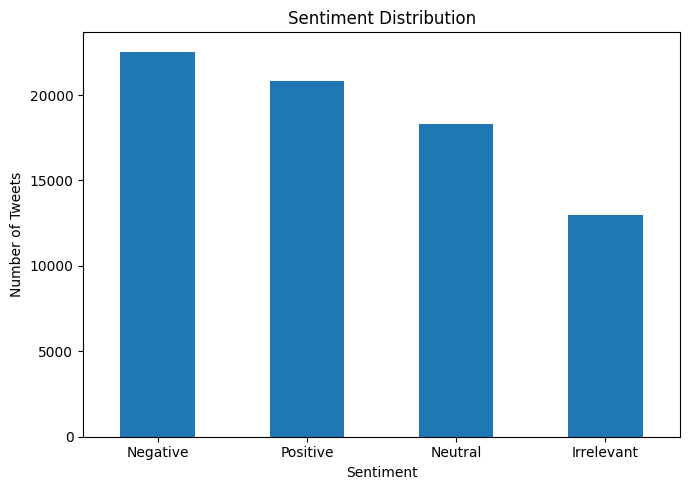

In [ ]:
# Step 12 — Sentiment Plot

plt.figure(figsize=(7, 5))

raw4["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Step 13 — Entity Distribution

entity_counts4 = raw4["entity"].value_counts()

print(
    "Number of unique entities:",
    raw4["entity"].nunique()
)

display(
    entity_counts4.head(20)
)

Number of unique entities: 32


,count
entity,
Microsoft,2400
MaddenNFL,2400
TomClancysRainbowSix,2400
LeagueOfLegends,2394
CallOfDuty,2394
Verizon,2382
CallOfDutyBlackopsColdWar,2376
ApexLegends,2376
Facebook,2370


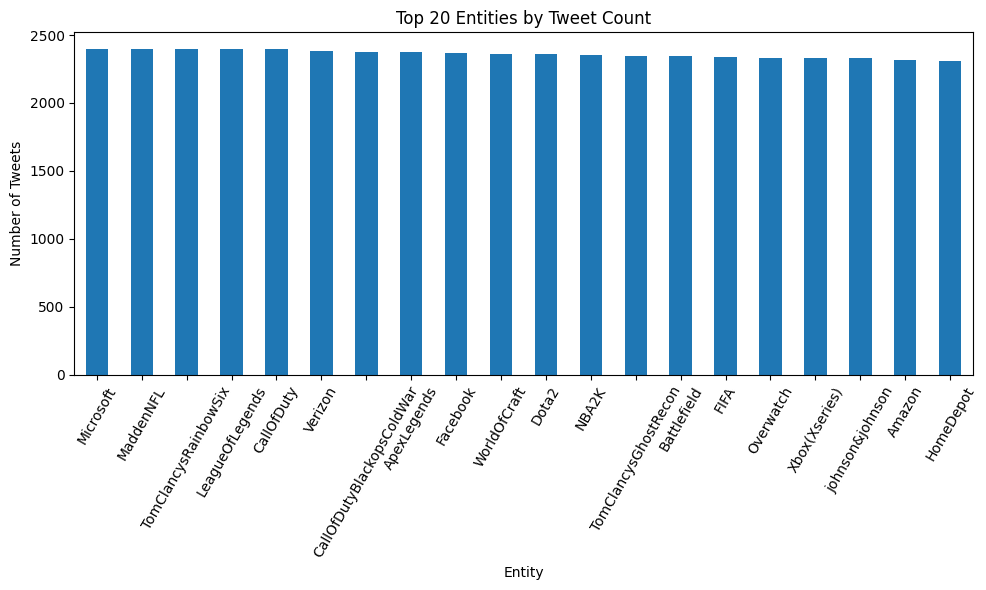

In [ ]:
# Step 14 — Entity Plot

plt.figure(figsize=(10, 6))

entity_counts4.head(20).plot(
    kind="bar"
)

plt.title("Top 20 Entities by Tweet Count")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [ ]:
# Step 15 — Entity Sentiment

entity_sentiment4 = pd.crosstab(
    raw4["entity"],
    raw4["sentiment"]
)

display(
    entity_sentiment4.head(20)
)

sentiment,Irrelevant,Negative,Neutral,Positive
entity,,,,
Amazon,192,576,1236,312
ApexLegends,192,600,942,642
AssassinsCreed,264,378,156,1446
Battlefield,918,474,360,594
Borderlands,240,426,600,1020
CS-GO,636,348,552,768
CallOfDuty,672,894,378,450
CallOfDutyBlackopsColdWar,576,576,360,864
Cyberpunk2077,480,390,468,966


In [ ]:
# Step 16 — Entity Sentiment Percentage

entity_sentiment_pct4 = (
    pd.crosstab(
        raw4["entity"],
        raw4["sentiment"],
        normalize="index"
    ) * 100
)

display(
    entity_sentiment_pct4
    .round(2)
    .head(20)
)

sentiment,Irrelevant,Negative,Neutral,Positive
entity,,,,
Amazon,8.29,24.87,53.37,13.47
ApexLegends,8.08,25.25,39.65,27.02
AssassinsCreed,11.76,16.84,6.95,64.44
Battlefield,39.13,20.20,15.35,25.32
Borderlands,10.50,18.64,26.25,44.62
CS-GO,27.60,15.10,23.96,33.33
CallOfDuty,28.07,37.34,15.79,18.80
CallOfDutyBlackopsColdWar,24.24,24.24,15.15,36.36
Cyberpunk2077,20.83,16.93,20.31,41.93


In [ ]:
# Step 17 — Tweet Length

raw4["tweet_length"] = (
    raw4["text"]
    .astype(str)
    .str.len()
)

raw4["word_count"] = (
    raw4["text"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    raw4[
        ["tweet_length", "word_count"]
    ].describe()
)

,tweet_length,word_count
count,74682.000000,74682.000000
mean,107.811963,19.059198
std,79.798839,14.480861
min,1.000000,0.000000
25%,45.000000,8.000000
50%,90.000000,15.000000
75%,152.000000,27.000000
max,957.000000,198.000000


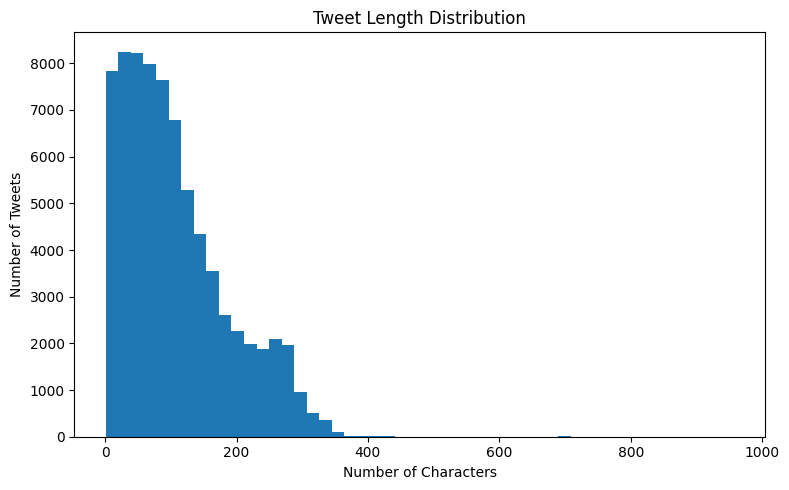

In [ ]:
# Step 18 — Tweet Length Plot

plt.figure(figsize=(8, 5))

plt.hist(
    raw4["tweet_length"],
    bins=50
)

plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()

In [ ]:
# Step 19 — Tweet Preprocessing

def normalize_tweet4(text):

    text = str(text)

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " <URL> ",
        text
    )

    text = re.sub(
        r"@\w+",
        " <USER> ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [ ]:
# Step 20 — Apply Preprocessing

raw4["clean_text"] = raw4["text"].apply(
    normalize_tweet4
)

display(
    raw4[
        ["text", "clean_text"]
    ].head(10)
)

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,I am coming to the borders and I will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you ...
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands 2 and i will murder ...
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
6,So I spent a few hours making something for fu...,So I spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...,So I spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...,So I spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...,So I spent a few hours making something for fu...


In [ ]:
# Step 21 — Remove Missing Data

raw4 = raw4.dropna(
    subset=[
        "clean_text",
        "sentiment",
        "entity"
    ]
).copy()

print("Shape after removing missing values:")
print(raw4.shape)

Shape after removing missing values:
(74682, 7)


In [ ]:
# Step 22 — Remove Duplicate IDs

before4 = len(raw4)

raw4 = raw4.drop_duplicates(
    subset="tweet_id",
    keep="first"
).reset_index(drop=True)

after4 = len(raw4)

print("Rows before:", before4)
print("Rows after:", after4)
print("Rows removed:", before4 - after4)

Rows before: 74682
Rows after: 12447
Rows removed: 62235


In [ ]:
# Step 23 — Final Modeling Data

model_df4 = raw4[
    [
        "tweet_id",
        "entity",
        "clean_text",
        "sentiment"
    ]
].copy()

print("Final modeling shape:", model_df4.shape)

display(
    model_df4.head()
)

Final modeling shape: (12447, 4)


,tweet_id,entity,clean_text,sentiment
0,2401,Borderlands,im getting on borderlands and i will murder yo...,Positive
1,2402,Borderlands,So I spent a few hours making something for fu...,Positive
2,2403,Borderlands,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM...",Neutral
3,2404,Borderlands,that was the first borderlands session in a lo...,Positive
4,2405,Borderlands,the biggest dissappoinment in my life came out...,Negative


In [ ]:
# Step 24 — Features and Target

X_text4 = model_df4["clean_text"]

y4 = model_df4["sentiment"]

entity_context4 = model_df4["entity"]

print("Samples:", len(X_text4))

print("\nClasses:")
print(sorted(y4.unique()))

Samples: 12447

Classes:
['Irrelevant', 'Negative', 'Neutral', 'Positive']


In [ ]:
# Step 25 — Class Mapping

class_names4 = sorted(
    y4.unique()
)

label2id4 = {
    label: index
    for index, label in enumerate(class_names4)
}

id2label4 = {
    index: label
    for label, index in label2id4.items()
}

print("Classes:", class_names4)
print("Label mapping:", label2id4)

Classes: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Label mapping: {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


In [ ]:
# Step 26 — Train Validation Test Split

X_train4, X_temp4, y_train4, y_temp4, entity_train4, entity_temp4 = train_test_split(
    X_text4,
    y4,
    entity_context4,
    test_size=0.30,
    random_state=SEED,
    stratify=y4
)

X_val4, X_test4, y_val4, y_test4, entity_val4, entity_test4 = train_test_split(
    X_temp4,
    y_temp4,
    entity_temp4,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp4
)

print("Training:", len(X_train4))
print("Validation:", len(X_val4))
print("Test:", len(X_test4))

Training: 8712
Validation: 1867
Test: 1868


In [ ]:
# Step 27 — Split Verification

split_distribution4 = pd.DataFrame({
    "Train": y_train4.value_counts(normalize=True) * 100,
    "Validation": y_val4.value_counts(normalize=True) * 100,
    "Test": y_test4.value_counts(normalize=True) * 100
}).round(2)

display(split_distribution4)

,Train,Validation,Test
sentiment,,,
Negative,30.19,30.16,30.19
Positive,27.89,27.91,27.89
Neutral,24.53,24.53,24.52
Irrelevant,17.39,17.41,17.40


In [ ]:
# Step 28 — Output Folders

OUTPUT_DIR4 = "dataset4_outputs"

FIGURE_DIR4 = os.path.join(
    OUTPUT_DIR4,
    "figures"
)

MODEL_DIR4 = os.path.join(
    OUTPUT_DIR4,
    "models"
)

ADVANCED_DIR4 = os.path.join(
    OUTPUT_DIR4,
    "advanced"
)

os.makedirs(FIGURE_DIR4, exist_ok=True)
os.makedirs(MODEL_DIR4, exist_ok=True)
os.makedirs(ADVANCED_DIR4, exist_ok=True)

print("Output folders created.")

Output folders created.


In [ ]:
# Step 29 — Save Split

split_indices4 = pd.DataFrame({
    "index": model_df4.index,
    "split": "unused"
})

split_indices4.loc[
    X_train4.index,
    "split"
] = "train"

split_indices4.loc[
    X_val4.index,
    "split"
] = "validation"

split_indices4.loc[
    X_test4.index,
    "split"
] = "test"

split_indices4.to_csv(
    os.path.join(
        OUTPUT_DIR4,
        "split_indices.csv"
    ),
    index=False
)

print(
    split_indices4["split"].value_counts()
)

split
train         8712
test          1868
validation    1867
Name: count, dtype: int64


In [ ]:
# Step 30 — DummyClassifier

dummy4 = DummyClassifier(
    strategy="most_frequent",
    random_state=SEED
)

dummy4.fit(
    X_train4,
    y_train4
)

dummy_pred4 = dummy4.predict(
    X_val4
)

dummy_accuracy4 = accuracy_score(
    y_val4,
    dummy_pred4
)

dummy_macro_f14 = f1_score(
    y_val4,
    dummy_pred4,
    average="macro"
)

print("Accuracy:", round(dummy_accuracy4, 4))
print("Macro F1:", round(dummy_macro_f14, 4))

print(
    classification_report(
        y_val4,
        dummy_pred4,
        digits=4
    )
)

Accuracy: 0.3016
Macro F1: 0.1158
              precision    recall  f1-score   support

  Irrelevant     0.0000    0.0000    0.0000       325
    Negative     0.3016    1.0000    0.4634       563
     Neutral     0.0000    0.0000    0.0000       458
    Positive     0.0000    0.0000    0.0000       521

    accuracy                         0.3016      1867
   macro avg     0.0754    0.2500    0.1158      1867
weighted avg     0.0909    0.3016    0.1397      1867



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Step 31 — VADER

vader4 = SentimentIntensityAnalyzer()

def vader_predict4(text):

    score = vader4.polarity_scores(
        str(text)
    )["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [ ]:
# Step 31A — VADER Label Matching

actual_labels4 = set(y_train4.unique())

label_lookup4 = {
    label.lower(): label
    for label in actual_labels4
}

def vader_predict_final4(text):

    prediction = vader_predict4(text)

    return label_lookup4.get(
        prediction.lower(),
        prediction
    )

vader_pred4 = X_val4.apply(
    vader_predict_final4
)

vader_accuracy4 = accuracy_score(
    y_val4,
    vader_pred4
)

vader_macro_f14 = f1_score(
    y_val4,
    vader_pred4,
    average="macro"
)

print("Accuracy:", round(vader_accuracy4, 4))
print("Macro F1:", round(vader_macro_f14, 4))

print(
    classification_report(
        y_val4,
        vader_pred4,
        digits=4
    )
)

Accuracy: 0.4253
Macro F1: 0.3265
              precision    recall  f1-score   support

  Irrelevant     0.0000    0.0000    0.0000       325
    Negative     0.4728    0.6021    0.5297       563
     Neutral     0.3392    0.2096    0.2591       458
    Positive     0.4141    0.6891    0.5173       521

    accuracy                         0.4253      1867
   macro avg     0.3065    0.3752    0.3265      1867
weighted avg     0.3413    0.4253    0.3676      1867



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Step 32 — Logistic Regression

logistic4 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED
        )
    )
])

logistic4.fit(
    X_train4,
    y_train4
)

logistic_pred4 = logistic4.predict(
    X_val4
)

logistic_accuracy4 = accuracy_score(
    y_val4,
    logistic_pred4
)

logistic_macro_f14 = f1_score(
    y_val4,
    logistic_pred4,
    average="macro"
)

logistic_weighted_f14 = f1_score(
    y_val4,
    logistic_pred4,
    average="weighted"
)

print("Accuracy:", round(logistic_accuracy4, 4))
print("Macro F1:", round(logistic_macro_f14, 4))
print("Weighted F1:", round(logistic_weighted_f14, 4))

print(
    classification_report(
        y_val4,
        logistic_pred4,
        digits=4
    )
)

Accuracy: 0.5747
Macro F1: 0.5491
Weighted F1: 0.5726
              precision    recall  f1-score   support

  Irrelevant     0.3645    0.3600    0.3622       325
    Negative     0.6557    0.7105    0.6820       563
     Neutral     0.5478    0.5000    0.5228       458
    Positive     0.6313    0.6276    0.6295       521

    accuracy                         0.5747      1867
   macro avg     0.5498    0.5495    0.5491      1867
weighted avg     0.5717    0.5747    0.5726      1867



In [ ]:
# Step 33 — LinearSVC

linear_svc4 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            random_state=SEED
        )
    )
])

linear_svc4.fit(
    X_train4,
    y_train4
)

linear_svc_pred4 = linear_svc4.predict(
    X_val4
)

linear_svc_accuracy4 = accuracy_score(
    y_val4,
    linear_svc_pred4
)

linear_svc_macro_f14 = f1_score(
    y_val4,
    linear_svc_pred4,
    average="macro"
)

linear_svc_weighted_f14 = f1_score(
    y_val4,
    linear_svc_pred4,
    average="weighted"
)

print("Accuracy:", round(linear_svc_accuracy4, 4))
print("Macro F1:", round(linear_svc_macro_f14, 4))
print("Weighted F1:", round(linear_svc_weighted_f14, 4))

print(
    classification_report(
        y_val4,
        linear_svc_pred4,
        digits=4
    )
)

Accuracy: 0.5576
Macro F1: 0.5319
Weighted F1: 0.5536
              precision    recall  f1-score   support

  Irrelevant     0.3785    0.3354    0.3556       325
    Negative     0.6161    0.6785    0.6458       563
     Neutral     0.5330    0.4934    0.5125       458
    Positive     0.6056    0.6219    0.6136       521

    accuracy                         0.5576      1867
   macro avg     0.5333    0.5323    0.5319      1867
weighted avg     0.5514    0.5576    0.5536      1867



In [ ]:
# Step 33A — Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_validate

cv4 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_scoring4 = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

logistic_cv4 = cross_validate(
    logistic4,
    X_train4,
    y_train4,
    cv=cv4,
    scoring=cv_scoring4,
    n_jobs=-1
)

linear_svc_cv4 = cross_validate(
    linear_svc4,
    X_train4,
    y_train4,
    cv=cv4,
    scoring=cv_scoring4,
    n_jobs=-1
)

print("Cross-validation completed.")

Cross-validation completed.


In [ ]:
# Step 33B — CV Results

cv_results4 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LinearSVC"
    ],
    "CV Macro F1 Mean": [
        logistic_cv4["test_macro_f1"].mean(),
        linear_svc_cv4["test_macro_f1"].mean()
    ],
    "CV Macro F1 SD": [
        logistic_cv4["test_macro_f1"].std(),
        linear_svc_cv4["test_macro_f1"].std()
    ],
    "CV Weighted F1 Mean": [
        logistic_cv4["test_weighted_f1"].mean(),
        linear_svc_cv4["test_weighted_f1"].mean()
    ],
    "CV Accuracy Mean": [
        logistic_cv4["test_accuracy"].mean(),
        linear_svc_cv4["test_accuracy"].mean()
    ]
})

cv_results4.round(4)

,Model,CV Macro F1 Mean,CV Macro F1 SD,CV Weighted F1 Mean,CV Accuracy Mean
0,Logistic Regression,0.5400,0.0031,0.5597,0.5606
1,LinearSVC,0.5216,0.0084,0.5414,0.5445


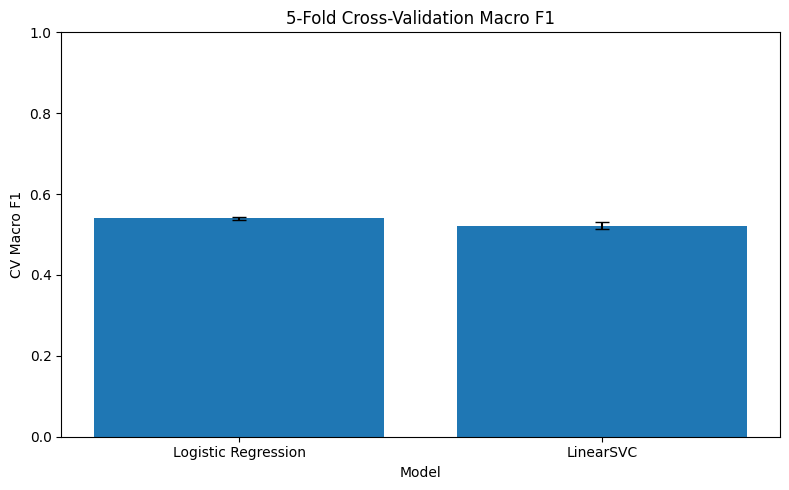

In [ ]:
# Step 33C — CV Macro F1 Plot

plt.figure(figsize=(8, 5))

plt.bar(
    cv_results4["Model"],
    cv_results4["CV Macro F1 Mean"],
    yerr=cv_results4["CV Macro F1 SD"],
    capsize=5
)

plt.xlabel("Model")
plt.ylabel("CV Macro F1")
plt.title("5-Fold Cross-Validation Macro F1")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

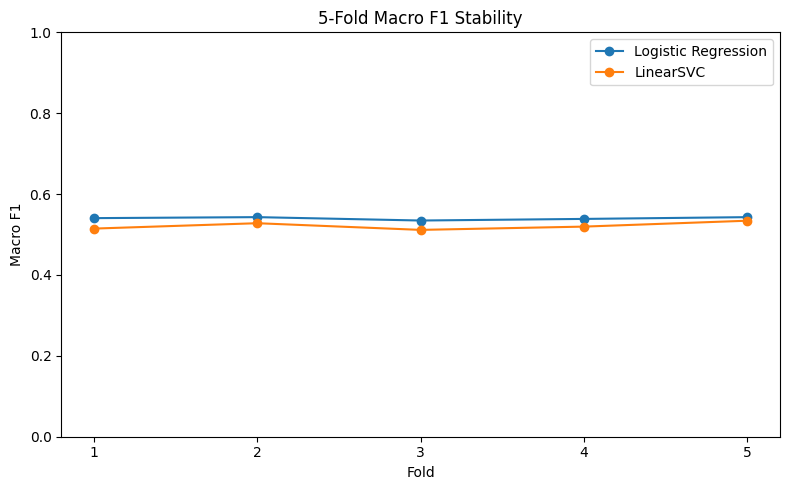

In [ ]:
# Step 33D — Fold Stability Plot

fold_scores4 = pd.DataFrame({
    "Fold": range(1, 6),
    "Logistic Regression": logistic_cv4["test_macro_f1"],
    "LinearSVC": linear_svc_cv4["test_macro_f1"]
})

plt.figure(figsize=(8, 5))

plt.plot(
    fold_scores4["Fold"],
    fold_scores4["Logistic Regression"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    fold_scores4["Fold"],
    fold_scores4["LinearSVC"],
    marker="o",
    label="LinearSVC"
)

plt.xlabel("Fold")
plt.ylabel("Macro F1")
plt.title("5-Fold Macro F1 Stability")
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

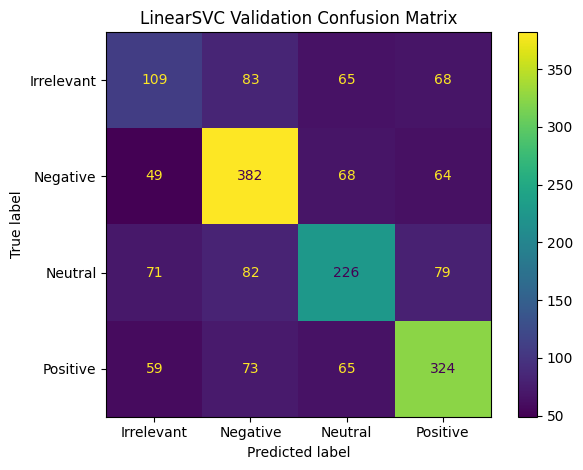

In [ ]:
# Step 34 — LinearSVC Confusion Matrix

cm4 = confusion_matrix(
    y_val4,
    linear_svc_pred4,
    labels=class_names4
)

ConfusionMatrixDisplay(
    confusion_matrix=cm4,
    display_labels=class_names4
).plot()

plt.title(
    "LinearSVC Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
# Step 35 — BiLSTM Tokenization

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS4 = 30000
MAX_LENGTH4 = 80

tokenizer4 = Tokenizer(
    num_words=MAX_WORDS4,
    oov_token="<OOV>"
)

tokenizer4.fit_on_texts(
    X_train4.tolist()
)

X_train_seq4 = tokenizer4.texts_to_sequences(
    X_train4.tolist()
)

X_val_seq4 = tokenizer4.texts_to_sequences(
    X_val4.tolist()
)

X_test_seq4 = tokenizer4.texts_to_sequences(
    X_test4.tolist()
)

X_train_pad4 = pad_sequences(
    X_train_seq4,
    maxlen=MAX_LENGTH4,
    padding="post",
    truncating="post"
)

X_val_pad4 = pad_sequences(
    X_val_seq4,
    maxlen=MAX_LENGTH4,
    padding="post",
    truncating="post"
)

X_test_pad4 = pad_sequences(
    X_test_seq4,
    maxlen=MAX_LENGTH4,
    padding="post",
    truncating="post"
)

print(X_train_pad4.shape)
print(X_val_pad4.shape)
print(X_test_pad4.shape)

(8712, 80)
(1867, 80)
(1868, 80)


In [ ]:
# Step 36 — BiLSTM Labels

y_train_encoded4 = y_train4.map(
    label2id4
).values

y_val_encoded4 = y_val4.map(
    label2id4
).values

y_test_encoded4 = y_test4.map(
    label2id4
).values

print(label2id4)

{'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


In [ ]:
# Step 37 — BiLSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

NUM_CLASSES4 = len(class_names4)

bilstm4 = Sequential([
    Embedding(
        input_dim=MAX_WORDS4,
        output_dim=128,
        input_length=MAX_LENGTH4
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.4),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES4,
        activation="softmax"
    )
])

bilstm4.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm4.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 38 — BiLSTM Class Weights

from sklearn.utils.class_weight import compute_class_weight

classes4 = np.unique(
    y_train_encoded4
)

weights4 = compute_class_weight(
    class_weight="balanced",
    classes=classes4,
    y=y_train_encoded4
)

class_weights4 = dict(
    zip(
        classes4,
        weights4
    )
)

print(class_weights4)

{np.int64(0): np.float64(1.4376237623762376), np.int64(1): np.float64(0.8281368821292776), np.int64(2): np.float64(1.0191857744501638), np.int64(3): np.float64(0.8962962962962963)}


In [ ]:
# Step 39 — BiLSTM Training

from tensorflow.keras.callbacks import EarlyStopping

early_stop4 = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

bilstm_start4 = time.time()

history4 = bilstm4.fit(
    X_train_pad4,
    y_train_encoded4,
    validation_data=(
        X_val_pad4,
        y_val_encoded4
    ),
    epochs=8,
    batch_size=64,
    class_weight=class_weights4,
    callbacks=[early_stop4],
    verbose=1
)

bilstm_time4 = time.time() - bilstm_start4

print(
    "Training time:",
    round(bilstm_time4, 2),
    "seconds"
)

Epoch 1/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3670 - loss: 1.3237 - val_accuracy: 0.5104 - val_loss: 1.1666
Epoch 2/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5929 - loss: 1.0233 - val_accuracy: 0.5560 - val_loss: 1.1404
Epoch 3/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7625 - loss: 0.6670 - val_accuracy: 0.5335 - val_loss: 1.2577
Epoch 4/8
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8615 - loss: 0.4059 - val_accuracy: 0.5212 - val_loss: 1.5678
Training time: 17.4 seconds


In [ ]:
# Step 40 — BiLSTM Validation

bilstm_prob4 = bilstm4.predict(
    X_val_pad4,
    verbose=0
)

bilstm_encoded4 = np.argmax(
    bilstm_prob4,
    axis=1
)

bilstm_pred4 = [
    id2label4[i]
    for i in bilstm_encoded4
]

bilstm_accuracy4 = accuracy_score(
    y_val4,
    bilstm_pred4
)

bilstm_macro_f14 = f1_score(
    y_val4,
    bilstm_pred4,
    average="macro"
)

bilstm_weighted_f14 = f1_score(
    y_val4,
    bilstm_pred4,
    average="weighted"
)

print("Accuracy:", round(bilstm_accuracy4, 4))
print("Macro F1:", round(bilstm_macro_f14, 4))
print("Weighted F1:", round(bilstm_weighted_f14, 4))

print(
    classification_report(
        y_val4,
        bilstm_pred4,
        digits=4
    )
)

Accuracy: 0.556
Macro F1: 0.5227
Weighted F1: 0.5482
              precision    recall  f1-score   support

  Irrelevant     0.3843    0.2554    0.3068       325
    Negative     0.6228    0.6803    0.6503       563
     Neutral     0.4877    0.5633    0.5228       458
    Positive     0.6193    0.6027    0.6109       521

    accuracy                         0.5560      1867
   macro avg     0.5285    0.5254    0.5227      1867
weighted avg     0.5472    0.5560    0.5482      1867



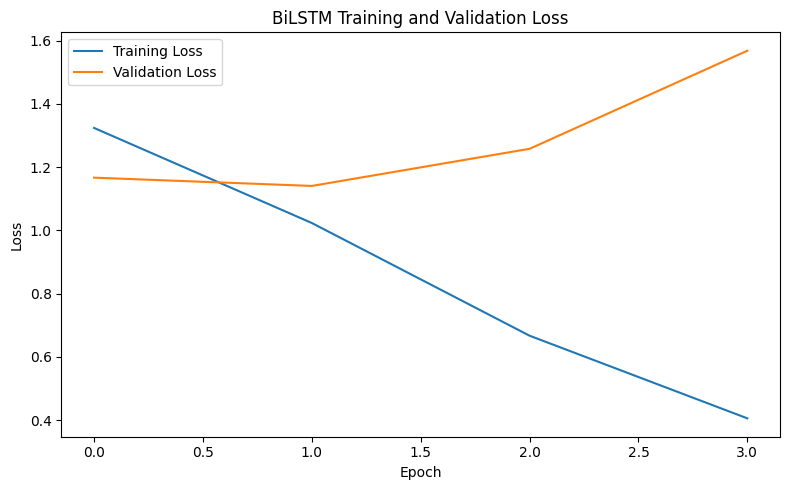

In [ ]:
# Step 41 — BiLSTM Loss Plot

plt.figure(figsize=(8, 5))

plt.plot(
    history4.history["loss"],
    label="Training Loss"
)

plt.plot(
    history4.history["val_loss"],
    label="Validation Loss"
)

plt.title("BiLSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Step 42 — BERTweet Tokenizer

BERTWEET_MODEL4 = "vinai/bertweet-base"

bertweet_tokenizer4 = AutoTokenizer.from_pretrained(
    BERTWEET_MODEL4,
    use_fast=False
)

print("BERTweet tokenizer loaded.")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


BERTweet tokenizer loaded.


In [ ]:
# Step 43 — BERTweet Dataset

class TweetDataset4(TorchDataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=128
    ):

        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):

        encoding = self.tokenizer(
            str(self.texts[index]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            key: value.squeeze(0)
            for key, value in encoding.items()
        }

        item["labels"] = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return item

In [ ]:
# Step 44 — BERTweet Data

train_dataset4 = TweetDataset4(
    X_train4,
    y_train4.map(label2id4),
    bertweet_tokenizer4
)

val_dataset4 = TweetDataset4(
    X_val4,
    y_val4.map(label2id4),
    bertweet_tokenizer4
)

test_dataset4 = TweetDataset4(
    X_test4,
    y_test4.map(label2id4),
    bertweet_tokenizer4
)

print("Train:", len(train_dataset4))
print("Validation:", len(val_dataset4))
print("Test:", len(test_dataset4))

Train: 8712
Validation: 1867
Test: 1868


In [ ]:
# Step 45 — BERTweet Model

bertweet4 = AutoModelForSequenceClassification.from_pretrained(
    BERTWEET_MODEL4,
    num_labels=NUM_CLASSES4,
    id2label=id2label4,
    label2id=label2id4,
    ignore_mismatched_sizes=True
)

print("BERTweet model loaded.")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTweet model loaded.


In [ ]:
# Step 46 — BERTweet Metrics

def compute_metrics4(eval_prediction):

    logits, labels = eval_prediction

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro"
        ),

        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted"
        )
    }

In [ ]:
# Step 47 — BERTweet Training Setup

training_args4 = TrainingArguments(
    output_dir="./bertweet_dataset4",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    fp16=torch.cuda.is_available()
)

In [ ]:
# Step 48 — BERTweet Trainer

trainer4 = Trainer(
    model=bertweet4,
    args=training_args4,

    train_dataset=train_dataset4,
    eval_dataset=val_dataset4,

    processing_class=bertweet_tokenizer4,

    compute_metrics=compute_metrics4
)

print("Trainer ready.")

Trainer ready.


In [ ]:
# Step 49 — BERTweet Training

bertweet_start4 = time.time()

trainer4.train()

bertweet_time4 = time.time() - bertweet_start4

print(
    "Training time:",
    round(bertweet_time4, 2),
    "seconds"
)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.020197,0.926511,0.633101,0.585406,0.615893
2,0.841094,0.919361,0.642207,0.611406,0.636374
3,0.683460,0.951101,0.643814,0.611459,0.637266


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 265.84 seconds


In [ ]:
# Step 50 — BERTweet Validation

bertweet_eval4 = trainer4.evaluate(
    eval_dataset=val_dataset4
)

print(bertweet_eval4)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.683460,0.951101,3,0.643814,0.611459,0.637266


{'eval_loss': 0.951100766658783, 'eval_accuracy': 0.6438136047134441, 'eval_macro_f1': 0.6114593096469002, 'eval_weighted_f1': 0.6372661689144848}


In [ ]:
# Step 51 — BERTweet Test

bertweet_test4 = trainer4.predict(
    test_dataset4
)

bertweet_test_encoded4 = np.argmax(
    bertweet_test4.predictions,
    axis=1
)

bertweet_test_pred4 = [
    id2label4[i]
    for i in bertweet_test_encoded4
]

bertweet_accuracy4 = accuracy_score(
    y_test4,
    bertweet_test_pred4
)

bertweet_macro_f14 = f1_score(
    y_test4,
    bertweet_test_pred4,
    average="macro"
)

bertweet_weighted_f14 = f1_score(
    y_test4,
    bertweet_test_pred4,
    average="weighted"
)

print("Accuracy:", round(bertweet_accuracy4, 4))
print("Macro F1:", round(bertweet_macro_f14, 4))
print("Weighted F1:", round(bertweet_weighted_f14, 4))

print(
    classification_report(
        y_test4,
        bertweet_test_pred4,
        digits=4
    )
)

Accuracy: 0.6424
Macro F1: 0.6112
Weighted F1: 0.6351
              precision    recall  f1-score   support

  Irrelevant     0.4980    0.3754    0.4281       325
    Negative     0.7093    0.7872    0.7462       564
     Neutral     0.5773    0.5546    0.5657       458
    Positive     0.6822    0.7294    0.7050       521

    accuracy                         0.6424      1868
   macro avg     0.6167    0.6116    0.6112      1868
weighted avg     0.6326    0.6424    0.6351      1868



In [ ]:
# Step 52 — Model Comparison

results4 = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "VADER",
        "Logistic Regression",
        "LinearSVC",
        "BiLSTM",
        "BERTweet"
    ],

    "Accuracy": [
        dummy_accuracy4,
        vader_accuracy4,
        logistic_accuracy4,
        linear_svc_accuracy4,
        bilstm_accuracy4,
        bertweet_accuracy4
    ],

    "Macro_F1": [
        dummy_macro_f14,
        vader_macro_f14,
        logistic_macro_f14,
        linear_svc_macro_f14,
        bilstm_macro_f14,
        bertweet_macro_f14
    ]
})

display(
    results4.sort_values(
        "Macro_F1",
        ascending=False
    )
)

,Model,Accuracy,Macro_F1
5,BERTweet,0.642398,0.611250
2,Logistic Regression,0.574719,0.549131
3,LinearSVC,0.557579,0.531888
4,BiLSTM,0.555972,0.522696
1,VADER,0.425281,0.326522
0,DummyClassifier,0.301553,0.115844


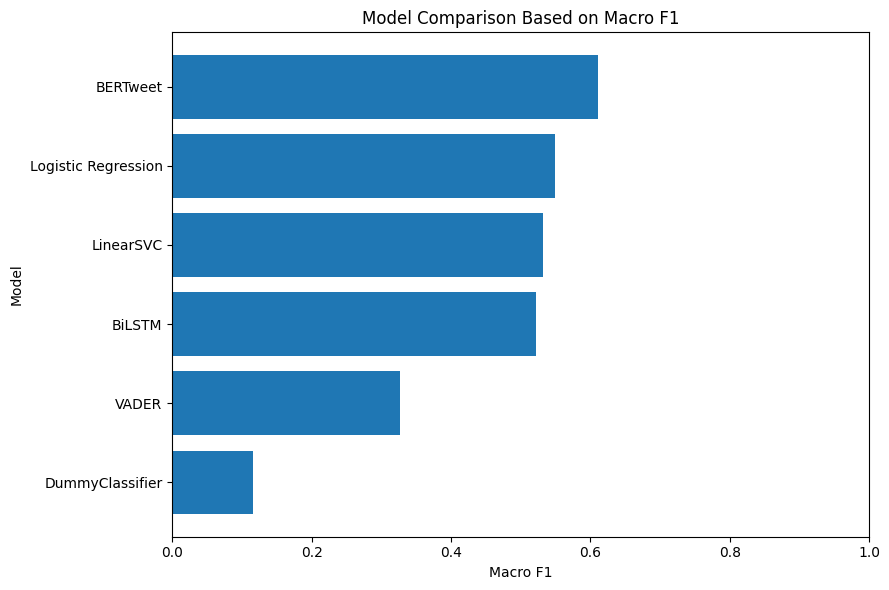

In [ ]:
# Step 53 — Best Model Plot

plot_data4 = results4.sort_values(
    "Macro_F1",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data4["Model"],
    plot_data4["Macro_F1"]
)

plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.title("Model Comparison Based on Macro F1")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

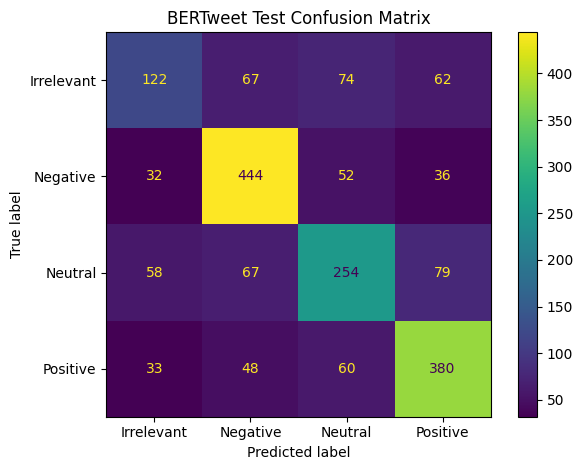

In [ ]:
# Step 54 — Final Confusion Matrix

final_cm4 = confusion_matrix(
    y_test4,
    bertweet_test_pred4,
    labels=class_names4
)

ConfusionMatrixDisplay(
    confusion_matrix=final_cm4,
    display_labels=class_names4
).plot()

plt.title(
    "BERTweet Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
# Step 55 — Error Analysis

error_df4 = pd.DataFrame({
    "Tweet": X_test4.reset_index(drop=True),
    "Entity": entity_test4.reset_index(drop=True),
    "Actual": y_test4.reset_index(drop=True),
    "Predicted": bertweet_test_pred4
})

errors4 = error_df4[
    error_df4["Actual"] != error_df4["Predicted"]
].copy()

print(
    "Total errors:",
    len(errors4)
)

display(
    errors4.head(10)
)

Total errors: 668


,Tweet,Entity,Actual,Predicted
2,people really said screw sadie adler,RedDeadRedemption(RDR),Neutral,Negative
9,<USER> is live once again playing some LoL mak...,LeagueOfLegends,Neutral,Irrelevant
10,I Hit Those . . . medal.tv/clips/18127096… <URL>,Fortnite,Positive,Neutral
13,It’s almost as if my Facebook heard me say I’m...,Facebook,Neutral,Negative
17,Royal Never Give Up looking really good! Vici ...,LeagueOfLegends,Neutral,Positive
21,"Damn, Tobi :(",Dota2,Irrelevant,Negative
28,<USER> is the ai training bots can practice go...,Overwatch,Irrelevant,Negative
30,"I'll hop on this 10 games to know me train, no...",WorldOfCraft,Neutral,Positive
32,Sony can destroy gamepass if the PS5 is fully ...,Microsoft,Negative,Positive
33,What a cutie! < 3 Check out my screenshot from...,WorldOfCraft,Positive,Neutral


In [ ]:
# Step 56 — Entity Error Analysis

entity_errors4 = (
    errors4.groupby("Entity")
    .size()
    .reset_index(
        name="Errors"
    )
)

entity_total4 = (
    entity_test4
    .value_counts()
    .reset_index()
)

entity_total4.columns = [
    "Entity",
    "Total"
]

entity_error4 = entity_total4.merge(
    entity_errors4,
    on="Entity",
    how="left"
)

entity_error4["Errors"] = (
    entity_error4["Errors"]
    .fillna(0)
)

entity_error4["Error_Rate"] = (
    entity_error4["Errors"] /
    entity_error4["Total"] * 100
).round(2)

display(
    entity_error4.sort_values(
        "Error_Rate",
        ascending=False
    ).head(20)
)

,Entity,Total,Errors,Error_Rate
30,PlayStation5(PS5),50,25,50.00
21,Google,56,28,50.00
11,Facebook,61,30,49.18
24,LeagueOfLegends,54,26,48.15
13,Fortnite,59,25,42.37
26,PlayerUnknownsBattlegrounds(PUBG),53,22,41.51
6,FIFA,63,26,41.27
4,GrandTheftAuto(GTA),63,26,41.27
15,CS-GO,59,24,40.68
16,Microsoft,59,24,40.68


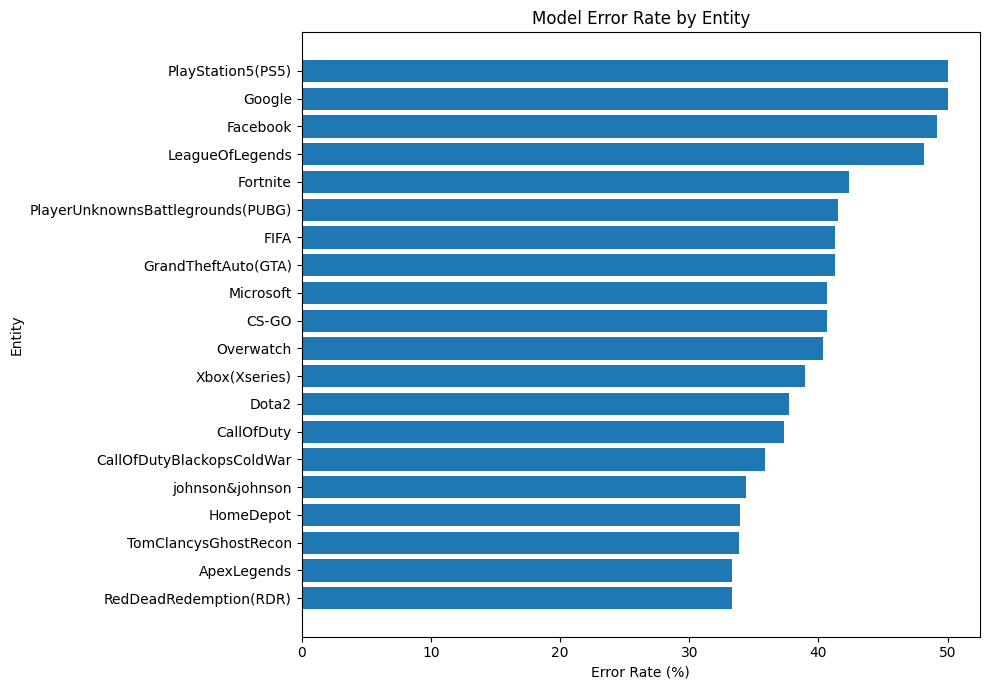

In [ ]:
# Step 57 — Entity Error Plot

plot_entity4 = entity_error4[
    entity_error4["Total"] >= 20
].sort_values(
    "Error_Rate",
    ascending=True
).tail(20)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_entity4["Entity"],
    plot_entity4["Error_Rate"]
)

plt.xlabel("Error Rate (%)")
plt.ylabel("Entity")
plt.title("Model Error Rate by Entity")

plt.tight_layout()
plt.show()

In [ ]:
# Step 58 — Save Classical Models

joblib.dump(
    logistic4,
    os.path.join(
        MODEL_DIR4,
        "logistic_regression.joblib"
    )
)

joblib.dump(
    linear_svc4,
    os.path.join(
        MODEL_DIR4,
        "linear_svc.joblib"
    )

)

print("Classical models saved.")

Classical models saved.


In [ ]:
# Step 59 — Save BERTweet

trainer4.save_model(
    os.path.join(
        MODEL_DIR4,
        "bertweet_model"
    )
)

bertweet_tokenizer4.save_pretrained(
    os.path.join(
        MODEL_DIR4,
        "bertweet_model"
    )
)

print("BERTweet saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERTweet saved.


In [ ]:


# Step 60 — Save Predictions

prediction4 = pd.DataFrame({
    "Tweet": X_test4.reset_index(drop=True),
    "Entity": entity_test4.reset_index(drop=True),
    "Actual": y_test4.reset_index(drop=True),
    "Predicted": bertweet_test_pred4
})

prediction4.to_csv(
    os.path.join(
        OUTPUT_DIR4,
        "Test_Predictions.csv"
    ),
    index=False
)

print("Predictions saved.")

Predictions saved.


In [ ]:
# Step 61 — Save Error Analysis

errors4.to_csv(
    os.path.join(
        OUTPUT_DIR4,
        "Error_Analysis.csv"
    ),
    index=False
)

print("Error analysis saved.")

Error analysis saved.


In [ ]:
# Step 62 — Reload Test

loaded_logistic4 = joblib.load(
    os.path.join(
        MODEL_DIR4,
        "logistic_regression.joblib"
    )
)

sample_prediction4 = loaded_logistic4.predict(
    [
        "This game was absolutely amazing!"
    ]
)

print(
    "Prediction:",
    sample_prediction4[0]
)

Prediction: Positive


In [ ]:
# Step 63 — Final Summary

print("Dataset 4 completed.")
print()
print("Dataset shape:", model_df4.shape)
print("Classes:", class_names4)
print("Train:", len(X_train4))
print("Validation:", len(X_val4))
print("Test:", len(X_test4))

print("\nModel Results:")
display(
    results4.sort_values(
        "Macro_F1",
        ascending=False
    )
)

Dataset 4 completed.

Dataset shape: (12447, 4)
Classes: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Train: 8712
Validation: 1867
Test: 1868

Model Results:


,Model,Accuracy,Macro_F1
5,BERTweet,0.642398,0.611250
2,Logistic Regression,0.574719,0.549131
3,LinearSVC,0.557579,0.531888
4,BiLSTM,0.555972,0.522696
1,VADER,0.425281,0.326522
0,DummyClassifier,0.301553,0.115844
